# Part 3: Hedging with Real SPX Option Data

Delta hedging strategies for SPX index European call options using real WRDS market data (Feb 2023).  
Dataset: SPX call option quotes 2023-02-01 to 2023-02-28.

**Setup.** Import libraries (numpy, pandas, scipy, matplotlib, seaborn) and set display options. Needed for all data loading, computation, and plotting in the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from pathlib import Path
import ssl
import urllib.request
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('.')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)
print('Environment ready.')

Environment ready.


**Data inventory.** List all CSV files in the project directory with row counts. Verifies that the WRDS option file (`option20230201_20230228.csv`) is present before loading.

## Data Inventory

**List CSV files.** Scan the project directory for CSV files and print row counts. Confirms the WRDS file is present and shows relative sizes of available datasets.

In [3]:
files = list(DATA_DIR.glob('*.csv'))
for f in sorted(files):
    n_rows = sum(1 for _ in open(f)) - 1
    print(f'{f.name:50s}  {n_rows:>8,} rows')

Call_option_data_2025-04-03_final.csv                    124 rows
HedgingScoreboard.csv                                     56 rows
Put_option_data_2025-04-03_final.csv                     175 rows
option20230201_20230228.csv                          175,301 rows
option20230228.csv                                    18,382 rows


**Key column dtypes and non-null counts.** Check data quality for columns used in hedging: date, symbol, strike, bid/offer, implied vol, delta. Identifies missing-value rates before filtering.

## Quick peek at the WRDS option panel

**Preview raw data.** The next cells load the WRDS CSV and inspect structure, dtypes, and key distributions before cleaning.

**Load CSV.** Read the option panel and show shape, columns, and first rows.

**Load raw WRDS option panel.** Read the CSV and inspect shape, columns, and first rows. Establishes the `raw` DataFrame for exploratory checks before Step 1 cleaning.

In [4]:
raw = pd.read_csv(DATA_DIR / 'option20230201_20230228.csv')
print(f'Shape: {raw.shape}')
print(f'\nColumns ({len(raw.columns)}):')
print(list(raw.columns))
raw.head(3)

Shape: (175301, 38)

Columns (38):
['secid', 'date', 'symbol', 'symbol_flag', 'exdate', 'last_date', 'cp_flag', 'strike_price', 'best_bid', 'best_offer', 'volume', 'open_interest', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta', 'optionid', 'cfadj', 'am_settlement', 'contract_size', 'ss_flag', 'forward_price', 'expiry_indicator', 'root', 'suffix', 'cusip', 'ticker', 'sic', 'index_flag', 'exchange_d', 'class', 'issue_type', 'industry_group', 'issuer', 'div_convention', 'exercise_style', 'am_set_flag']


,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,ss_flag,forward_price,expiry_indicator,root,suffix,cusip,ticker,sic,index_flag,exchange_d,class,issue_type,industry_group,issuer,div_convention,exercise_style,am_set_flag
0,108105,2023-02-01,SPX 230217C1000000,1,2023-02-17,2023-01-26,C,1000000,3111.0,3118.5,0,9776,NaN,NaN,NaN,NaN,NaN,144702199,1,1,100,0,NaN,NaN,NaN,NaN,64881510,SPX,9999,1,32768,NaN,A,NaN,CBOE S&P 500 INDEX,I,E,NaN
1,108105,2023-02-01,SPX 230217C1200000,1,2023-02-17,2022-07-28,C,1200000,2911.5,2919.1,0,0,NaN,NaN,NaN,NaN,NaN,144702200,1,1,100,0,NaN,NaN,NaN,NaN,64881510,SPX,9999,1,32768,NaN,A,NaN,CBOE S&P 500 INDEX,I,E,NaN
2,108105,2023-02-01,SPX 230217C1300000,1,2023-02-17,NaN,C,1300000,2811.6,2819.7,0,0,NaN,NaN,NaN,NaN,NaN,144702201,1,1,100,0,NaN,NaN,NaN,NaN,64881510,SPX,9999,1,32768,NaN,A,NaN,CBOE S&P 500 INDEX,I,E,NaN


**Key column dtypes and non-null counts.** Report data quality for columns used in hedging (date, symbol, strike, bid/offer, implied vol, delta). Identifies missing-value rates before filtering.

In [5]:
print('=== Key column dtypes & non-null counts ===')
key_cols = ['date', 'symbol', 'exdate', 'cp_flag', 'strike_price',
            'best_bid', 'best_offer', 'impl_volatility', 'delta',
            'gamma', 'vega', 'theta', 'forward_price']
for c in key_cols:
    non_null = raw[c].notna().sum()
    pct = non_null / len(raw) * 100
    print(f'  {c:25s}  {non_null:>8,} / {len(raw):,}  ({pct:.1f}%)  dtype={raw[c].dtype}')

=== Key column dtypes & non-null counts ===
  date                        175,301 / 175,301  (100.0%)  dtype=str
  symbol                      175,301 / 175,301  (100.0%)  dtype=str
  exdate                      175,301 / 175,301  (100.0%)  dtype=str
  cp_flag                     175,301 / 175,301  (100.0%)  dtype=str
  strike_price                175,301 / 175,301  (100.0%)  dtype=int64
  best_bid                    175,301 / 175,301  (100.0%)  dtype=float64
  best_offer                  175,301 / 175,301  (100.0%)  dtype=float64
  impl_volatility             153,728 / 175,301  (87.7%)  dtype=float64
  delta                       153,728 / 175,301  (87.7%)  dtype=float64
  gamma                       153,728 / 175,301  (87.7%)  dtype=float64
  vega                        153,728 / 175,301  (87.7%)  dtype=float64
  theta                       153,728 / 175,301  (87.7%)  dtype=float64
  forward_price                     0 / 175,301  (0.0%)  dtype=float64


**Dataset structure.** Show cp_flag distribution, unique dates/expiries, and strike range. Confirms calls-only and strike scale (raw vs rescaled by 1000).

In [6]:
print('cp_flag distribution:')
print(raw['cp_flag'].value_counts())
print(f"\nUnique dates:   {raw['date'].nunique()}")
print(f"Unique expiries: {raw['exdate'].nunique()}")
print(f"\nStrike range: {raw['strike_price'].min()} – {raw['strike_price'].max()}")
print(f'(After /1000:  {raw["strike_price"].min()/1000:.0f} – {raw["strike_price"].max()/1000:.0f})')

cp_flag distribution:
cp_flag
C    175301
Name: count, dtype: int64

Unique dates:   19
Unique expiries: 68

Strike range: 100000 – 12000000
(After /1000:  100 – 12000)


---
## Step 1: Data Loading and Cleaning

**Step 1 implementation.** Load WRDS CSV, filter to calls, convert dates, rescale strikes (÷1000), compute midquote V, drop rows with missing/invalid implied vol, keep required columns, and print all required reporting metrics.

In [7]:
# --- Step 1: Data Loading and Cleaning ---
WRDS_FILE = DATA_DIR / 'option20230201_20230228.csv'
df = pd.read_csv(WRDS_FILE)

# 1) Filter to calls only
n_raw = len(df)
df = df[df['cp_flag'] == 'C'].copy()
n_after_calls = len(df)

# 2) Convert dates to datetime
df['date'] = pd.to_datetime(df['date'])
df['exdate'] = pd.to_datetime(df['exdate'])

# 3) Rescale strikes (SPX: divide by 1000)
df['strike'] = df['strike_price'] / 1000

# 4) Compute midquote V
df['V'] = (df['best_bid'] + df['best_offer']) / 2

# 5) Remove missing/invalid implied volatility
# Invalid: NaN, <= 0, or > 5 (500% vol is unreasonable)
sigma = df['impl_volatility']
valid_iv = sigma.notna() & (sigma > 0) & (sigma <= 5)
df = df[valid_iv].copy()
n_after_iv = len(df)

# Keep columns needed for the project
KEEP_COLS = ['date', 'exdate', 'symbol', 'strike', 'best_bid', 'best_offer', 'V', 
             'impl_volatility', 'delta', 'gamma', 'vega', 'theta']
df = df[[c for c in KEEP_COLS if c in df.columns]].copy()

# --- Required reporting ---
print("=== Step 1: Data Loading and Cleaning ===\n")
print(f"Row count (raw):                    {n_raw:>10,}")
print(f"Row count (after calls filter):     {n_after_calls:>10,}")
print(f"Row count (after IV filter):        {n_after_iv:>10,}")
print(f"\nUnique trading dates:               {df['date'].nunique():>10,}")
print(f"Unique expiries:                   {df['exdate'].nunique():>10,}")

# Missing rates (on the filtered sample)
n = len(df)
miss_V = df['V'].isna().sum()
miss_sigma = df['impl_volatility'].isna().sum()
miss_delta = df['delta'].isna().sum()
print(f"\nMissing rates (on final sample):")
print(f"  V_t (midquote):     {miss_V:>6,} / {n:,}  ({100*miss_V/n:.2f}%)")
print(f"  σ_mkt (impl vol):   {miss_sigma:>6,} / {n:,}  ({100*miss_sigma/n:.2f}%)")
print(f"  δ (vendor delta):   {miss_delta:>6,} / {n:,}  ({100*miss_delta/n:.2f}%)")

print(f"\nFinal columns kept ({len(df.columns)}):")
print(list(df.columns))

=== Step 1: Data Loading and Cleaning ===

Row count (raw):                       175,301
Row count (after calls filter):        175,301
Row count (after IV filter):           153,728

Unique trading dates:                       19
Unique expiries:                           67

Missing rates (on final sample):
  V_t (midquote):          0 / 153,728  (0.00%)
  σ_mkt (impl vol):        0 / 153,728  (0.00%)
  δ (vendor delta):        0 / 153,728  (0.00%)

Final columns kept (12):
['date', 'exdate', 'symbol', 'strike', 'best_bid', 'best_offer', 'V', 'impl_volatility', 'delta', 'gamma', 'vega', 'theta']


## Step 2: Contract Time Series and One-Day Option Changes

**Step 2 implementation.** Build contract IDs (from symbol), compute one-day option changes ΔV_t = V_{t+1} − V_t, and keep only rows where both V_t and V_{t+1} exist.

In [8]:
# --- Step 2: Contract Time Series and One-Day Option Changes ---
# Contract ID = symbol (unique per strike/expiry)
df['contract_id'] = df['symbol']

# Sort by (symbol, date) so shift(-1) gives next day within each contract
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

# Compute ΔV_t = V_{t+1} - V_t within each contract
df['dV'] = df.groupby('symbol')['V'].transform(lambda x: x.shift(-1) - x)

# Drop rows where ΔV_t is NaN (last observation per contract has no next day)
df = df.dropna(subset=['dV']).copy()
n_contracts = df['symbol'].nunique()

# --- Required reporting ---
print("=== Step 2: Contract Time Series and One-Day Option Changes ===\n")
print("Summary statistics of V_t:")
print(df['V'].describe().to_string())
print("\nSummary statistics of ΔV_t:")
print(df['dV'].describe().to_string())
print(f"\nNumber of contracts retained: {n_contracts:,}")

=== Step 2: Contract Time Series and One-Day Option Changes ===

Summary statistics of V_t:
count    141619.000000
mean        430.754198
std         578.585187
min           0.025000
25%          36.400000
50%         206.450000
75%         600.850000
max        4022.700000

Summary statistics of ΔV_t:
count    141619.000000
mean         -6.315655
std          27.128320
min        -170.300000
25%         -22.200000
50%          -2.150000
75%           5.100000
max          70.200000

Number of contracts retained: 11,593


## Step 3: Underlying SPX Merge and One-Day Changes

**Step 3 implementation.** Download SPX close series, compute ΔS_t = S_{t+1} − S_t, and merge S_t and ΔS_t into the option panel by date.

=== Step 3: Underlying SPX Merge and One-Day Changes ===

Merge coverage: 141,619 / 141,619 (100.00%) of option rows matched to valid (S_t, ΔS_t)

Summary statistics of S_t:
count    141619.000000
mean       4085.065277
std          64.690452
min        3970.040000
25%        4012.320000
50%        4090.460000
75%        4136.480000
max        4179.760000

Summary statistics of ΔS_t:
count    141619.000000
mean         -8.476981
std          37.850399
min         -81.750000
25%         -42.280000
50%         -11.320000
75%          12.200000
max          60.550000


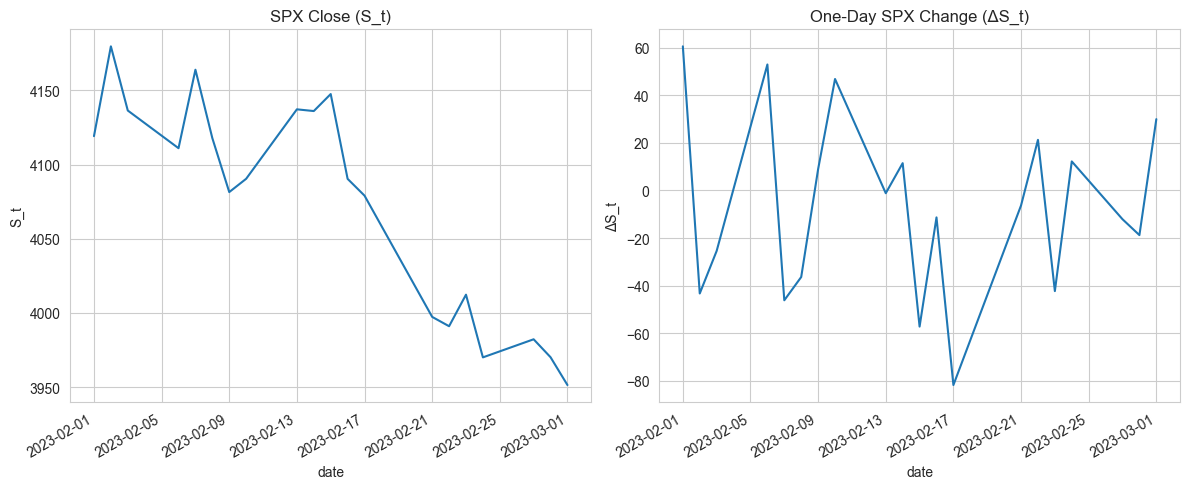

In [9]:
# --- Step 3: Underlying SPX Merge and One-Day Changes ---


start = "2023-02-01"
end = "2023-03-02"
d1 = pd.Timestamp(start).strftime("%Y%m%d")
d2 = pd.Timestamp(end).strftime("%Y%m%d")
url = f"https://stooq.com/q/d/l/?s=^spx&d1={d1}&d2={d2}&i=d"

# Use SSL context to avoid certificate verification errors (common on macOS)
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE
with urllib.request.urlopen(url, context=ctx) as resp:
    spx_raw = pd.read_csv(resp, parse_dates=["Date"]).sort_values("Date")
spx_raw = spx_raw.rename(columns={"Date": "date", "Close": "S"})
spx_raw["date"] = pd.to_datetime(spx_raw["date"]).dt.normalize()

# Compute ΔS_t = S_{t+1} - S_t
spx_raw["dS"] = spx_raw["S"].shift(-1) - spx_raw["S"]
spx = spx_raw[["date", "S", "dS"]].dropna(subset=["dS"])

# Merge into option panel by date
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
n_before = len(df)
df = df.merge(spx, on="date", how="left")
n_after = (df["S"].notna() & df["dS"].notna()).sum()
merge_pct = 100 * n_after / n_before if n_before > 0 else 0

# --- Required reporting ---
print("=== Step 3: Underlying SPX Merge and One-Day Changes ===\n")
print(f"Merge coverage: {n_after:,} / {n_before:,} ({merge_pct:.2f}%) of option rows matched to valid (S_t, ΔS_t)")
print("\nSummary statistics of S_t:")
print(df["S"].describe().to_string())
print("\nSummary statistics of ΔS_t:")
print(df["dS"].describe().to_string())

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
spx_plot = spx.set_index("date")
spx_plot["S"].plot(ax=axes[0], title="SPX Close (S_t)")
axes[0].set_ylabel("S_t")
spx_plot["dS"].plot(ax=axes[1], title="One-Day SPX Change (ΔS_t)")
axes[1].set_ylabel("ΔS_t")
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'spx_close_dS.png', dpi=100)
plt.show()

## Step 4: Nelson-Siegel-Svensson Yield Curve

**Step 4 implementation.** Fit Nelson–Siegel–Svensson yield curves to Treasury par yields for each date, extract r_t(τ), and compute discount factors and forwards for each option.

=== Step 4a: Treasury Data and Date Alignment ===

Option trading dates: 18
Treasury rows (aligned): 18
Dates with any missing yield: 0
✓ Every option date has a full set of yields.
=== Step 4b: Grid search (test on one date) ===
Test date: 2023-02-01
Best (τ1, τ2) = (0.5, 20)
β = [0.0257072  0.01791356 0.0402685  0.03208268]
SSE = 2.877914e-06


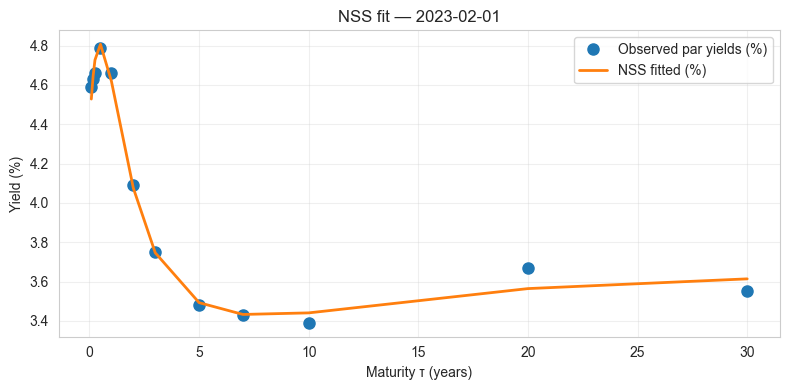


=== Full grid search (all dates) ===
β shape: (18, 4)
(τ1, τ2) range: τ1 ∈ [0.5, 1.0], τ2 ∈ [1.5, 20.0]


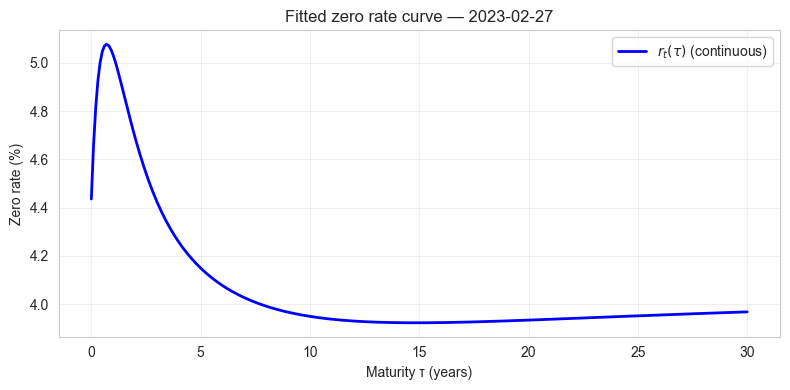

=== Step 4c–d: r_t(τ), P_t(τ), F_t(τ) ===
                 tau          y_hat              r              P              F
count  141619.000000  141619.000000  141619.000000  141619.000000  141619.000000
mean        0.365355       0.047291       0.046740       0.983606    4155.908673
std         0.615157       0.001909       0.001866       0.024101     130.402260
min         0.005479       0.034580       0.034284       0.818506    3972.046828
25%         0.063014       0.046038       0.045516       0.981158    4091.341942
50%         0.183562       0.047137       0.046590       0.991354    4144.799872
75%         0.394521       0.048550       0.047970       0.997132    4193.962940
max         4.876712       0.051419       0.050769       0.999763    5029.951225

✓ All finite (τ, ŷ, r, P, F): True


In [10]:


from locale import D_FMT


TREASURY_URL = (
    "https://home.treasury.gov/resource-center/data-chart-center/interest-rates/"
    "daily-treasury-rate-archives/par-yield-curve-rates-2020-2023.csv"
)

# Download (with SSL workaround if needed)
try:
    treasury_raw = pd.read_csv(TREASURY_URL)
except Exception:
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(TREASURY_URL, context=ctx) as resp:
        treasury_raw = pd.read_csv(resp)

# Parse dates
treasury_raw["date"] = pd.to_datetime(treasury_raw["date"]).dt.normalize()

# Map column names to tenor (years); Treasury uses "1 mo", "2 mo", "1 yr", etc.
# Assignment tenors: 1/12, 2/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30
COL_TO_TENOR = {
    "1 mo": 1/12, "2 mo": 2/12, "3 mo": 3/12, "6 mo": 6/12,
    "1 yr": 1, "2 yr": 2, "3 yr": 3, "5 yr": 5, "7 yr": 7,
    "10 yr": 10, "20 yr": 20, "30 yr": 30,
}
tenors = [1/12, 2/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]

# Build yield panel: keep only columns we can map, convert % to decimals
treasury = treasury_raw[["date"]].copy()
for col, m in COL_TO_TENOR.items():
    if col in treasury_raw.columns:
        treasury[m] = pd.to_numeric(treasury_raw[col], errors="coerce") / 100

# Option trading dates
opt_dates = df["date"].dropna().unique()
opt_dates = pd.DatetimeIndex(sorted(opt_dates))

# Forward-fill Treasury to option dates (Treasury not recorded on weekends/holidays)
treasury = treasury.set_index("date").sort_index()
treasury_aligned = treasury.reindex(opt_dates, method="ffill")

# Backward-fill at start if needed
treasury_aligned = treasury_aligned.bfill()

# Verify: every option date has a full set of yields
missing = treasury_aligned[tenors].isna().any(axis=1).sum()
print("=== Step 4a: Treasury Data and Date Alignment ===\n")
print(f"Option trading dates: {len(opt_dates)}")
print(f"Treasury rows (aligned): {len(treasury_aligned)}")
print(f"Dates with any missing yield: {missing}")
if missing == 0:
    print("✓ Every option date has a full set of yields.")
else:
    print(f"⚠ {missing} dates have missing yields — check forward-fill.")

# τ guard: avoid division by zero in g1 when τ/λ → 0 (limit = 1)
def g1(tau, lam):
    x = tau / lam
    return np.where(x < 1e-10, 1.0, (1 - np.exp(-x)) / x)
def g2(tau, lam): return g1(tau, lam) - np.exp(-tau/lam)
def g3(tau, lam): return g1(tau, lam) - np.exp(-tau/lam)  # same form, uses τ2

def build_X(tenors, tau1, tau2):
    X = np.ones((len(tenors), 4))
    for j, m in enumerate(tenors):
        m_safe = max(m, 1/365)  # guard per assignment
        X[j, 1] = g1(m_safe, tau1)
        X[j, 2] = g2(m_safe, tau1)
        X[j, 3] = g3(m_safe, tau2)
    return X

# Grid: τ1 ∈ [0.5, 1, 1.5, 2, 3, 5], τ2 ∈ [τ1, ..., 10, 15, 20]
tau1_grid = [0.5, 1, 1.5, 2, 3, 5]
tau2_extended = [0.5, 1, 1.5, 2, 3, 5, 10, 15, 20]

def fit_nss_one_date(y_t, tenors, tau1_grid, tau2_extended):
    """For one date's yields y_t, grid-search (τ1,τ2) and return best SSE, beta, tau1, tau2."""
    best_sse, best_beta, best_tau1, best_tau2 = np.inf, None, None, None
    for tau1 in tau1_grid:
        for tau2 in tau2_extended:
            if tau2 <= tau1:  # τ2 > τ1 required; τ2=τ1 makes g2=g3 → singular X
                continue
            X = build_X(tenors, tau1, tau2)
            beta = np.linalg.inv(X.T @ X) @ X.T @ y_t
            y_hat = X @ beta
            sse = np.sum((y_t - y_hat) ** 2)
            if sse < best_sse:
                best_sse, best_beta, best_tau1, best_tau2 = sse, beta.copy(), tau1, tau2
    return best_beta, best_tau1, best_tau2

# Test on one date first
test_date_idx = 0
y_test = treasury_aligned[tenors].iloc[test_date_idx].values
beta_test, tau1_test, tau2_test = fit_nss_one_date(y_test, tenors, tau1_grid, tau2_extended)
X_test = build_X(tenors, tau1_test, tau2_test)
y_fit_test = X_test @ beta_test
print("=== Step 4b: Grid search (test on one date) ===")
print(f"Test date: {treasury_aligned.index[test_date_idx].strftime('%Y-%m-%d')}")
print(f"Best (τ1, τ2) = ({tau1_test}, {tau2_test})")
print(f"β = {beta_test}")
print(f"SSE = {np.sum((y_test - y_fit_test)**2):.6e}")

# Plot fitted vs observed for verification
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tenors, y_test * 100, 'o', label='Observed par yields (%)', markersize=8)
ax.plot(tenors, y_fit_test * 100, '-', label='NSS fitted (%)', lw=2)
ax.set_xlabel('Maturity τ (years)')
ax.set_ylabel('Yield (%)')
ax.set_title(f'NSS fit — {treasury_aligned.index[test_date_idx].strftime("%Y-%m-%d")}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'nss_fitted_curve.png', dpi=100)
plt.show()

# Full grid search for all dates
betas_list, tau1_list, tau2_list = [], [], []
for i, (_, row) in enumerate(treasury_aligned[tenors].iterrows()):
    y_t = row.values
    beta_t, t1, t2 = fit_nss_one_date(y_t, tenors, tau1_grid, tau2_extended)
    betas_list.append(beta_t)
    tau1_list.append(t1)
    tau2_list.append(t2)

beta = np.array(betas_list)  # (n_dates, 4)
nss_tau1 = np.array(tau1_list)
nss_tau2 = np.array(tau2_list)

print("\n=== Full grid search (all dates) ===")
print(f"β shape: {beta.shape}")
print(f"(τ1, τ2) range: τ1 ∈ [{nss_tau1.min()}, {nss_tau1.max()}], τ2 ∈ [{nss_tau2.min()}, {nss_tau2.max()}]")


# --- Step 4c–d: Evaluate NSS at option maturities, r_t(τ), P_t(τ), F_t(τ) ---

# Time to expiry in years
df['tau'] = (df['exdate'] - df['date']).dt.days / 365
df['tau'] = np.maximum(df['tau'], 1/365)

# NSS params lookup by date (merge so each row gets its date's β, τ1, τ2)
nss_params = pd.DataFrame({
    'date': opt_dates,
    'beta0': beta[:, 0], 'beta1': beta[:, 1], 'beta2': beta[:, 2], 'beta3': beta[:, 3],
    'nss_tau1': nss_tau1, 'nss_tau2': nss_tau2,
})
df = df.merge(nss_params, on='date', how='left')

# ŷ_t(τ) = β₀ + β₁·g1(τ,τ1) + β₂·g2(τ,τ1) + β₃·g3(τ,τ2)
df['y_hat'] = (
    df['beta0']
    + df['beta1'] * g1(df['tau'], df['nss_tau1'])
    + df['beta2'] * g2(df['tau'], df['nss_tau1'])
    + df['beta3'] * g3(df['tau'], df['nss_tau2'])
)

# Continuous zero rate: r_t(τ) = 2·ln(1 + ŷ/2)
df['r'] = 2 * np.log(1 + df['y_hat'] / 2)

# Discount factor and forward (q=0)
df['P'] = np.exp(-df['r'] * df['tau'])
df['F'] = df['S'] * np.exp(df['r'] * df['tau'])

# Plot fitted curve r_t(τ) for representative date (2023-02-28 or last in opt_dates)
rep_date = pd.Timestamp('2023-02-28').normalize()
rep_idx = np.where(opt_dates == rep_date)[0]
if len(rep_idx) == 0:
    rep_date = opt_dates[-1]  # 2023-02-28 dropped in Step 2 (no next-day dV)
    rep_idx = np.array([len(opt_dates) - 1])
if len(rep_idx) > 0:
    idx = rep_idx[0]
    b0, b1, b2, b3 = beta[idx, 0], beta[idx, 1], beta[idx, 2], beta[idx, 3]
    t1, t2 = nss_tau1[idx], nss_tau2[idx]
    tau_grid = np.linspace(1/365, 30, 300)
    y_grid = b0 + b1*g1(tau_grid, t1) + b2*g2(tau_grid, t1) + b3*g3(tau_grid, t2)
    r_grid = 2 * np.log(1 + y_grid / 2)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(tau_grid, r_grid * 100, 'b-', lw=2, label=r'$r_t(\tau)$ (continuous)')
    ax.set_xlabel('Maturity τ (years)')
    ax.set_ylabel('Zero rate (%)')
    ax.set_title(f'Fitted zero rate curve — {rep_date.strftime("%Y-%m-%d")}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'fitted_zero_rate_curve.png', dpi=100)
    plt.show()
else:
    print(f"Date {rep_date} not in opt_dates, skipping curve plot.")

# Verify all values finite
cols_check = ['tau', 'y_hat', 'r', 'P', 'F']
finite_ok = all(np.isfinite(df[c]).all() for c in cols_check)
print("=== Step 4c–d: r_t(τ), P_t(τ), F_t(τ) ===")
print(df[['tau', 'y_hat', 'r', 'P', 'F']].describe().to_string())
print(f"\n✓ All finite (τ, ŷ, r, P, F): {finite_ok}")
if not finite_ok:
    for c in cols_check:
        n_bad = (~np.isfinite(df[c])).sum()
        if n_bad > 0:
            print(f"  {c}: {n_bad} non-finite")

# Drop NSS param columns (keep y_hat, r, P, F)
df = df.drop(columns=['beta0', 'beta1', 'beta2', 'beta3', 'nss_tau1', 'nss_tau2'])



## Step 5: BS Delta Hedging and Performance

**Step 5a — BS delta.** Compute Black–Scholes delta ourselves (closed-form Φ(d1)) using S, K, τ, r_t(τ), σ_mkt. 


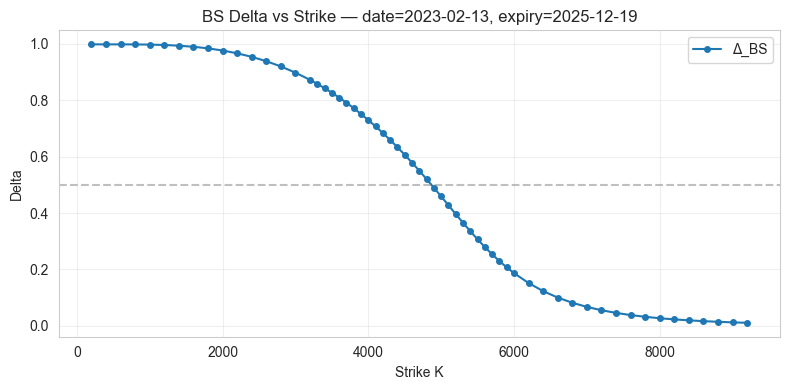

In [11]:
# Compute Black–Scholes delta ourselves (closed-form Φ(d1)) using F, K, τ, σ_mkt.
# d1 = [ln(F/K) + ½σ²τ] / (σ√τ) with F = S·e^(r_t(τ)·τ) from Step 4
def d1(F, K, tau, sigma):
    tau_safe = np.maximum(tau, 1/365)  # guard per assignment Step 4(d)
    return (np.log(F/K) + 0.5 * sigma**2 * tau_safe) / (sigma * np.sqrt(tau_safe))

df['delta_bs'] = norm.cdf(d1(df['F'], df['strike'], df['tau'], df['impl_volatility']))

# Sanity check: delta vs strike for one (date, exdate) slice — should be S-shaped (1→0)
slice_df = df.groupby(['date', 'exdate']).filter(lambda g: len(g) >= 10)
if len(slice_df) > 0:
    sample = slice_df.groupby(['date', 'exdate']).first().reset_index()
    d, ex = sample.iloc[len(sample)//2]['date'], sample.iloc[len(sample)//2]['exdate']
    sl = df[(df['date'] == d) & (df['exdate'] == ex)].sort_values('strike')
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sl['strike'], sl['delta_bs'], 'o-', markersize=4, label='Δ_BS')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Strike K')
    ax.set_ylabel('Delta')
    ax.set_title(f'BS Delta vs Strike — date={d.strftime("%Y-%m-%d")}, expiry={ex.strftime("%Y-%m-%d")}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'delta_vs_strike.png', dpi=100)
    plt.show()



**Step 5b–c — Residuals and filters.** Compute ε_t = ΔV_t − Δ_BS·ΔS_t, apply filters (0.05 ≤ Δ ≤ 0.95, D_t ≥ 14), and compute SSE and Gain (my BS vs vendor).

In [12]:
# TODO: Step 5b-c — residuals, filters, baseline SSE
df['residual'] = df['dV'] - df['delta_bs'] * df['dS']   # ε_t = ΔV_t − Δ_BS·ΔS_t
df['residual_v'] = df['dV'] - df['delta'] * df['dS']   # ε_t_vendor (for Gain comparison)
df['D_t'] = (df['exdate'] - df['date']).dt.days

print("\nSummary statistics of Residuals:")
print(df["residual"].describe().to_string())

# Mandatory filters — apply sequentially, print row count after EACH
df_filt = df.copy()
print(f"\nBefore filters:                    {len(df_filt):>10,}")

df_filt = df_filt[df_filt['delta_bs'] > 0.05]
print(f"After removing Δ_BS ≤ 0.05:        {len(df_filt):>10,}")

df_filt = df_filt[df_filt['delta_bs'] < 0.95]
print(f"After removing Δ_BS ≥ 0.95:        {len(df_filt):>10,}")

df_filt = df_filt[df_filt['D_t'] > 14]
print(f"After removing D_t ≤ 14:           {len(df_filt):>10,}")

# SSE and Gain on filtered sample
sse_bs = (df_filt['residual'] ** 2).sum()
sse_vendor = (df_filt['residual_v'] ** 2).sum()
gain = 1 - sse_bs / sse_vendor
print(f"\nSSE(my_BS):   {sse_bs:,.2f}")
print(f"SSE(vendor):  {sse_vendor:,.2f}")
print(f"Gain = 1 - SSE(my_BS)/SSE(vendor): {gain:.4f}  (≈ 0 if my delta is correct)")



Summary statistics of Residuals:
count    141619.000000
mean         -0.897599
std          10.005249
min        -170.858250
25%          -2.693804
50%          -0.052531
75%           1.979286
max         100.973965

Before filters:                       141,619
After removing Δ_BS ≤ 0.05:           122,381
After removing Δ_BS ≥ 0.95:            96,814
After removing D_t ≤ 14:               85,938

SSE(my_BS):   1,075,680.40
SSE(vendor):  967,056.86
Gain = 1 - SSE(my_BS)/SSE(vendor): -0.1123  (≈ 0 if my delta is correct)


**Step 5d — Misspecification study.** Hedge with different σ levels, compute SSE(σ), and plot SSE vs σ. 


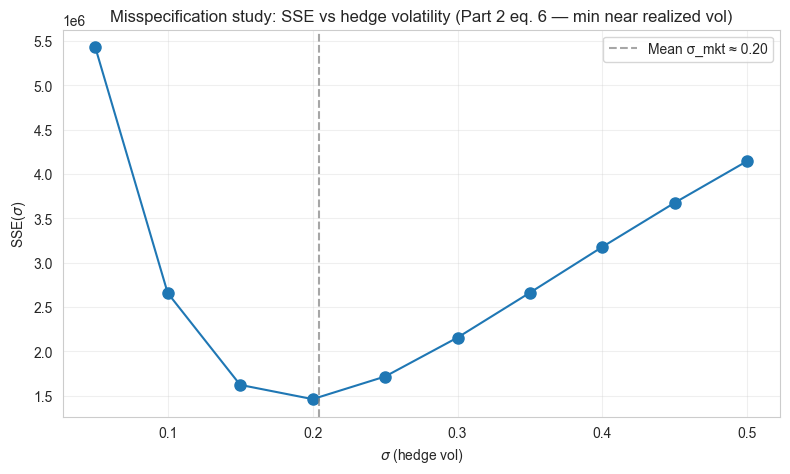

In [13]:
# Step 5d — Misspecification study: SSE vs σ
# For each σ in grid, hedge with Δ_BS(σ) (not σ_mkt) and compute SSE on filtered sample
sigma_grid = np.arange(0.05, 0.55, 0.05)  # 5% to 50%
sse_by_sigma = []

for sig in sigma_grid:
    delta_sig = norm.cdf(d1(df_filt['F'], df_filt['strike'], df_filt['tau'], sig))
    eps_sig = df_filt['dV'] - delta_sig * df_filt['dS']
    sse_sig = (eps_sig ** 2).sum()
    sse_by_sigma.append(sse_sig)

sse_by_sigma = np.array(sse_by_sigma)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sigma_grid, sse_by_sigma, 'o-', markersize=8)
ax.axvline(df_filt['impl_volatility'].mean(), color='gray', ls='--', alpha=0.7, label=f'Mean σ_mkt ≈ {df_filt["impl_volatility"].mean():.2f}')
ax.set_xlabel(r'$\sigma$ (hedge vol)')
ax.set_ylabel(r'SSE($\sigma$)')
ax.set_title('Misspecification study: SSE vs hedge volatility (Part 2 eq. 6 — min near realized vol)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sse_vs_sigma.png', dpi=100)
plt.show()

**Step 5e — Bucketing.** Create 9×7 grid (moneyness × maturity), assign rows to buckets using our BS delta, and compute SSE/MSE per bucket.

In [14]:
# 9 moneyness bins: equal-width over Δ_BS ∈ (0.05, 0.95)
delta_bins = np.linspace(0.05, 0.95, 10)  # 10 edges = 9 bins
# 7 maturity bins: equal-width over filtered D_t range
dte_bins = np.linspace(df_filt['D_t'].min(), df_filt['D_t'].max(), 8)  # 8 edges = 7 bins

# Assign each row to (moneyness_bucket, maturity_bucket) using my BS delta
df_filt = df_filt.copy()
df_filt['moneyness_bucket'] = pd.cut(df_filt['delta_bs'], bins=delta_bins, labels=range(9), include_lowest=True)
df_filt['maturity_bucket'] = pd.cut(df_filt['D_t'], bins=dte_bins, labels=range(7), include_lowest=True)

# Compute SSE, MSE, Gain per bucket (using my BS hedge)
bucket_stats = df_filt.groupby(['moneyness_bucket', 'maturity_bucket']).agg(
    sse_bs=('residual', lambda x: (x**2).sum()),
    sse_vendor=('residual_v', lambda x: (x**2).sum()),
    n=('residual', 'count'),
    mean_delta=('delta_bs', 'mean')
).reset_index()
bucket_stats['mse_bs'] = bucket_stats['sse_bs'] / bucket_stats['n']
bucket_stats['mse_vendor'] = bucket_stats['sse_vendor'] / bucket_stats['n']
bucket_stats['gain'] = 1 - bucket_stats['sse_bs'] / bucket_stats['sse_vendor']

# Pivot for heatmaps (rows=moneyness, cols=maturity)
sse_grid = bucket_stats.pivot(index='moneyness_bucket', columns='maturity_bucket', values='sse_bs')
mse_grid = bucket_stats.pivot(index='moneyness_bucket', columns='maturity_bucket', values='mse_bs')

# Print bucket counts (verify coverage)
print("Bucket counts (9×7 grid):")
count_grid = bucket_stats.pivot(index='moneyness_bucket', columns='maturity_bucket', values='n')
print(count_grid.to_string())
print(f"\nTotal rows in buckets: {count_grid.sum().sum():,}")

Bucket counts (9×7 grid):
maturity_bucket       0     1    2   4    5    6
moneyness_bucket                                
0                  5162   634  104  97  136   83
1                  4730   476   60  75   60   48
2                  5031   569   47  65   74   50
3                  5526   695   45  59   69   40
4                  6220   809   45  55   71   41
5                  7261  1032   53  64   75   45
6                  8948  1295   63  77   88   99
7                 11735  1816   85  95  108  115
8                 17917  3300  121  88   95  187

Total rows in buckets: 85,938


**Step 5f — Plots.** Smile (σ_mkt vs K), delta vs strike, SSE/MSE heatmaps across the 9×7 grid.

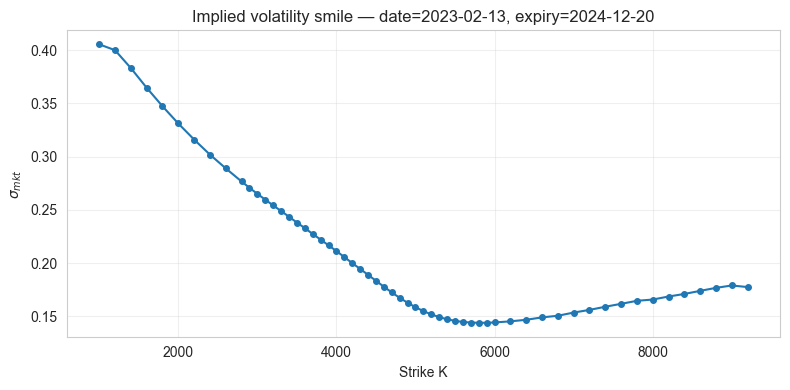

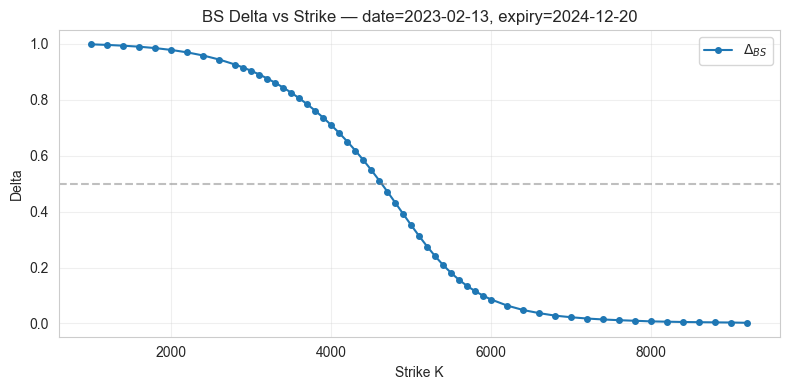

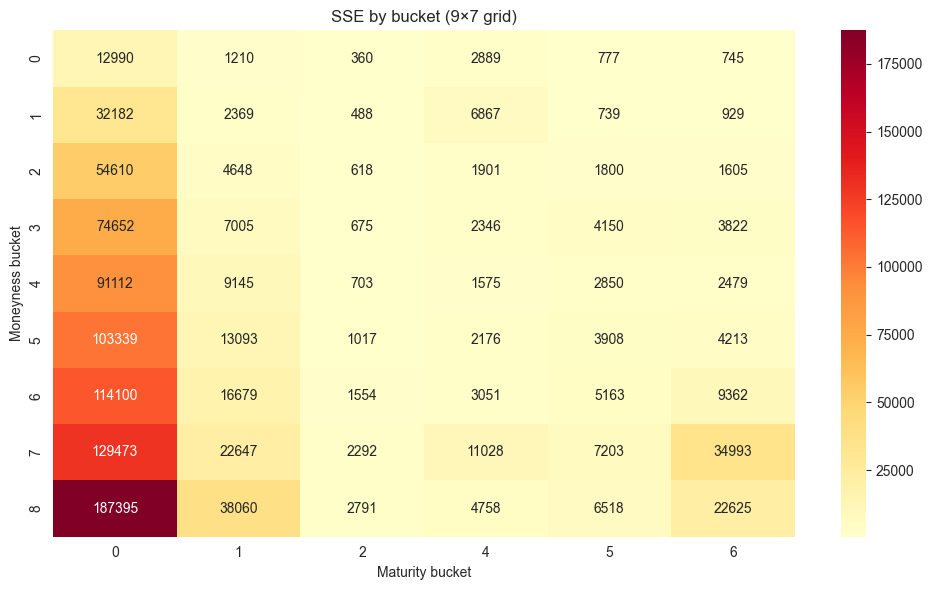

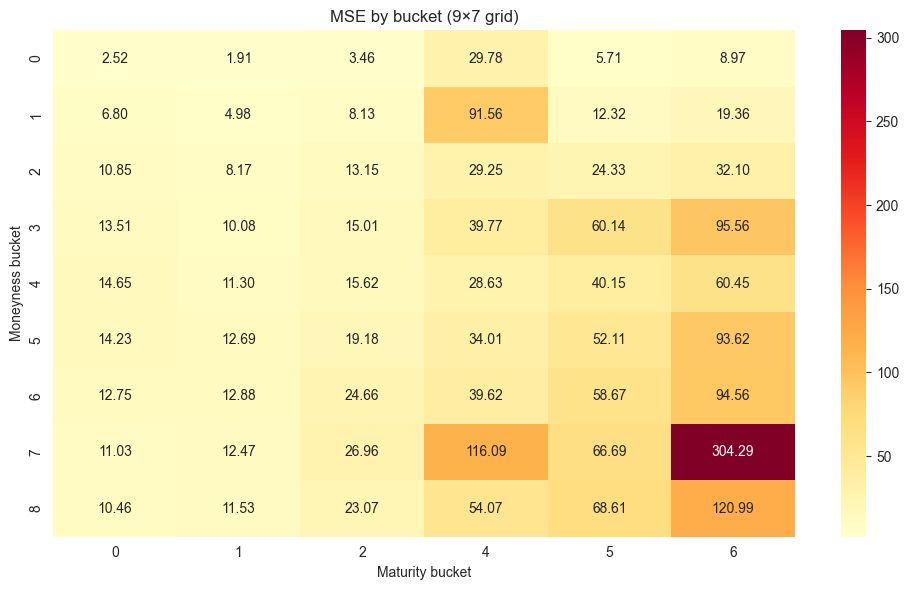

In [15]:
# Step 5f — All required plots
# Pick one (date, exdate) slice with enough strikes (from filtered sample)
slice_candidates = df_filt.groupby(['date', 'exdate']).size().reset_index(name='n')
slice_candidates = slice_candidates[slice_candidates['n'] >= 10]
if len(slice_candidates) > 0:
    d, ex = slice_candidates.iloc[len(slice_candidates)//2][['date', 'exdate']]
    sl = df[(df['date'] == d) & (df['exdate'] == ex)].sort_values('strike')

    # 1. Smile plot: σ_mkt vs K
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sl['strike'], sl['impl_volatility'], 'o-', markersize=4, color='C0')
    ax.set_xlabel('Strike K')
    ax.set_ylabel(r'$\sigma_{mkt}$')
    ax.set_title(f'Implied volatility smile — date={d.strftime("%Y-%m-%d")}, expiry={ex.strftime("%Y-%m-%d")}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'smile.png', dpi=100)
    plt.show()

    # 2. Delta vs strike (same slice)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sl['strike'], sl['delta_bs'], 'o-', markersize=4, label=r'$\Delta_{BS}$')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Strike K')
    ax.set_ylabel('Delta')
    ax.set_title(f'BS Delta vs Strike — date={d.strftime("%Y-%m-%d")}, expiry={ex.strftime("%Y-%m-%d")}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'delta_vs_strike_slice.png', dpi=100)
    plt.show()

# 3. SSE heatmap (9×7 grid)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(sse_grid, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Maturity bucket')
ax.set_ylabel('Moneyness bucket')
ax.set_title('SSE by bucket (9×7 grid)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sse_heatmap.png', dpi=100)
plt.show()

# 4. MSE heatmap (9×7 grid)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(mse_grid, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Maturity bucket')
ax.set_ylabel('Moneyness bucket')
ax.set_title('MSE by bucket (9×7 grid)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mse_heatmap.png', dpi=100)
plt.show()

## Step 6: Competition CSV Export

**Step 6 implementation.** Export HedgingScoreboard.csv with total and bucketed SSE/MSE, Gain metric, and delta information in 9×7 grid format.

In [16]:
# Step 6 — Export HedgingScoreboard.csv
# Delta used: my computed BS delta 
mse_total = sse_bs / len(df_filt)

# Build full scoreboard: total row + bucket rows
total_df = pd.DataFrame([{
    'moneyness_bin': 'TOTAL', 'maturity_bin': '',
    'SSE': sse_bs, 'MSE': mse_total, 'Gain': gain, 'n_obs': len(df_filt),
    'mean_delta': df_filt['delta_bs'].mean()
}])
bucket_export = bucket_stats[['moneyness_bucket', 'maturity_bucket', 'sse_bs', 'mse_bs', 'gain', 'n', 'mean_delta']].copy()
bucket_export.columns = ['moneyness_bin', 'maturity_bin', 'SSE', 'MSE', 'Gain', 'n_obs', 'mean_delta']
bucket_export['moneyness_bin'] = bucket_export['moneyness_bin'].astype(int)
bucket_export['maturity_bin'] = bucket_export['maturity_bin'].astype(int)

scoreboard = pd.concat([total_df, bucket_export], ignore_index=True)
scoreboard_path = DATA_DIR / 'HedgingScoreboard.csv'
with open(scoreboard_path, 'w') as f:
    f.write("# Delta used: my computed BS delta (not vendor)\n")
scoreboard.to_csv(scoreboard_path, mode='a', index=False)
print(f"Exported {scoreboard_path}")
print("\n--- Total level ---")
print(f"SSE: {sse_bs:,.2f} | MSE: {mse_total:.4f} | Gain: {gain:.4f} | n: {len(df_filt):,}")
print("\nScoreboard preview (first 5 bucket rows):")
print(bucket_export.head().to_string())
print("\n--- Verification ---")
with open(scoreboard_path) as f:
    lines = f.readlines()
print(f"CSV first 3 lines (delta source + header + total):")
for L in lines[:3]:
    print(" ", L.rstrip())


Exported HedgingScoreboard.csv

--- Total level ---
SSE: 1,075,680.40 | MSE: 12.5169 | Gain: -0.1123 | n: 85,938

Scoreboard preview (first 5 bucket rows):
   moneyness_bin  maturity_bin           SSE        MSE      Gain  n_obs  mean_delta
0              0             0  12990.112917   2.516488 -0.236732   5162    0.097810
1              0             1   1210.043709   1.908586 -0.789954    634    0.096345
2              0             2    360.120359   3.462696 -1.153289    104    0.098853
3              0             4   2889.061214  29.784136 -0.027805     97    0.090086
4              0             5    777.179671   5.714556 -0.543690    136    0.087720

--- Verification ---
CSV first 3 lines (delta source + header + total):
  # Delta used: my computed BS delta (not vendor)
  moneyness_bin,maturity_bin,SSE,MSE,Gain,n_obs,mean_delta
  TOTAL,,1075680.397409897,12.516935434963544,-0.11232383915457711,85938,0.6173569941425491
